# Research: Fama-French Factor ETF Rotation (Issue #25)

## Contexte
- **Performance actuelle**: Sharpe 0.365, CAGR 8.7%, MaxDD 31.1%
- **Problemes**: MaxDD 31% (TLT risk-off en 2022), momentum lookback non optimise, weighting arbitraire
- **Objectif**: Sharpe > 0.5, MaxDD < 20%

## Approche actuelle
- **Facteurs**: VLUE (valeur), MTUM (momentum), SIZE (petite cap), QUAL (qualite), USMV (low vol)
- **Signal**: Risk-adjusted momentum (60% 3m + 40% 12m), normalise par volatilite
- **Weighting**: Risk parity (inverse vol)
- **Risk-off**: TLT en marche baissiere (SPY < SMA200)

## Hypotheses a tester
1. **Risk-off asset**: TLT (+30% en 2022) vs Cash vs XLP+XLU vs USMV seul
2. **Momentum lookback**: 3m, 6m, 12m, composite (60/40 3m/12m)
3. **Weighting**: Equal vs Risk parity vs Momentum-weighted

## References
- Fama & French (2015) "A five-factor asset pricing model"
- Jegadeesh & Titman (1993) "Returns to Buying Winners and Selling Losers"
- Mebane Faber (2007) "Quantitative Approach to Tactical Asset Allocation"

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

## 1. Chargement des donnees

Telecharger les donnees yfinance pour tous les facteurs, SPY et les risk-off potentiels.

In [2]:
factor_tickers = ['VLUE', 'MTUM', 'SIZE', 'QUAL', 'USMV']
risk_off_tickers = ['TLT', 'XLP', 'XLU']
all_tickers = factor_tickers + risk_off_tickers + ['SPY']

print(f"Downloading {len(all_tickers)} tickers: {all_tickers}")
data = yf.download(all_tickers, start='2015-01-01', end='2026-01-01', progress=False)
closes = data['Close'].dropna()

print(f"\nPeriode: {closes.index[0].date()} a {closes.index[-1].date()}")
print(f"Donnees: {len(closes)} jours de trading")
print(f"\nFacteurs disponibles: {', '.join(factor_tickers)}")


Periode: 2015-01-02 a 2025-12-31
Donnees: 2766 jours de trading

Facteurs disponibles: VLUE, MTUM, SIZE, QUAL, USMV


### Interpretation: Performance buy-and-hold des facteurs

**Sortie obtenue**: Rendements annualises et volatilites de chaque facteur en buy-and-hold.

In [3]:
returns_df = closes.pct_change()

print(f"{'Ticker':<8} {'Ann. Return':>12} {'Volatilite':>12} {'Sharpe':>8}")
print("-" * 42)

factor_stats = {}
for ticker in all_tickers:
    ret = (closes[ticker].iloc[-1] / closes[ticker].iloc[0]) ** (252/len(closes)) - 1
    vol = returns_df[ticker].std() * np.sqrt(252)
    sharpe = (ret - 0.03) / vol if vol > 0 else 0
    factor_stats[ticker] = {'ret': ret, 'vol': vol, 'sharpe': sharpe}
    print(f"{ticker:<8} {ret:>11.1%} {vol:>11.1%} {sharpe:>7.2f}")

print(f"\nObservation: MTUM et SIZE les plus volatiles. USMV le moins volatil (par definition).")

Ticker    Ann. Return   Volatilite   Sharpe
------------------------------------------
VLUE            9.7%       19.3%    0.35
MTUM           14.0%       20.3%    0.54
SIZE           10.4%       18.4%    0.40
QUAL           12.8%       17.9%    0.55
USMV           10.0%       14.5%    0.48
TLT            -0.8%       15.0%   -0.25
XLP             7.2%       14.6%    0.29
XLU             9.0%       19.0%    0.31
SPY            13.5%       17.8%    0.59

Observation: MTUM et SIZE les plus volatiles. USMV le moins volatil (par definition).


## 2. Hypothese 1: Asset de risk-off

Tester l'impact du choix de l'asset lors d'une marche baissiere (SPY < SMA200). TLT a perdu 30 pct en 2022.

In [4]:
def factor_momentum_backtest(closes, factor_tickers, top_n=3, lookback=252, rebal_freq=21,
                             use_risk_off=True, risk_off_asset='TLT',
                             weighting='equal', vol_adjustment=False):
    returns_df = closes.pct_change()
    sma200 = closes['SPY'].rolling(200).mean()
    
    portfolio_values = [1.0]
    holdings_log = []
    rebal_counter = 0
    
    start_idx = max(lookback, 200) + 1
    
    for i in range(start_idx, len(closes)):
        if holdings_log:
            holdings = holdings_log[-1]['holdings']
            if len(holdings) > 0:
                port_ret = np.mean([returns_df[t].iloc[i] for t in holdings])
                portfolio_values.append(portfolio_values[-1] * (1 + port_ret))
            else:
                portfolio_values.append(portfolio_values[-1])
        else:
            portfolio_values.append(portfolio_values[-1])
        
        rebal_counter += 1
        if rebal_counter < rebal_freq:
            continue
        rebal_counter = 0
        
        spy_price = closes['SPY'].iloc[i]
        spy_sma = sma200.iloc[i]
        if pd.isna(spy_sma):
            continue
        
        risk_on = spy_price > spy_sma
        
        if not risk_on:
            if use_risk_off and risk_off_asset and risk_off_asset in closes.columns:
                holdings_log.append({'date': closes.index[i], 'holdings': [risk_off_asset]})
            else:
                holdings_log.append({'date': closes.index[i], 'holdings': []})
            continue
        
        scores = {}
        for t in factor_tickers:
            if t not in closes.columns:
                continue
            current = closes[t].iloc[i]
            past = closes[t].iloc[i - lookback]
            if past > 0:
                mom = current / past - 1
                if vol_adjustment:
                    vol = returns_df[t].iloc[max(0, i-63):i].std() * np.sqrt(252)
                    if vol > 0.01:
                        mom = mom / vol
                scores[t] = mom
        
        if len(scores) == 0:
            continue
        
        sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        top_factors = [t for t, s in sorted_scores[:min(top_n, len(sorted_scores))]]
        
        holdings_log.append({'date': closes.index[i], 'holdings': top_factors})
    
    returns = np.diff(portfolio_values) / np.array(portfolio_values[:-1])
    cum_returns = pd.Series(portfolio_values[1:])
    
    total_ret = (portfolio_values[-1] / portfolio_values[0]) - 1
    years = len(returns) / 252
    cagr = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0
    vol = np.std(returns) * np.sqrt(252) if len(returns) > 1 else 0
    sharpe = (cagr - 0.03) / vol if vol > 0.001 else 0
    
    running_max = cum_returns.expanding().max()
    drawdown = (cum_returns - running_max) / running_max
    max_dd = drawdown.min()
    
    return {
        'sharpe': sharpe,
        'cagr': cagr,
        'max_dd': max_dd,
        'vol': vol,
        'cum': cum_returns,
        'holdings': holdings_log
    }

print("Backtest function defined.")

Backtest function defined.


Affichage tabulaire des métriques Sharpe, CAGR pour chaque actif testé (CAGR, TLT) dans l'hypothèse 1 de FamaFrench.

In [5]:
print(f"{'Risk-off Asset':<15} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8} {'Vol':>8}")
print("-" * 50)

results_hyp1 = {}

n = 3
lb = 252

r = factor_momentum_backtest(closes, factor_tickers, top_n=n, lookback=lb, use_risk_off=True, risk_off_asset='TLT')
results_hyp1['TLT'] = r
print(f"{'TLT':<15} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%} {r['vol']:>7.1%}")

r = factor_momentum_backtest(closes, factor_tickers, top_n=n, lookback=lb, use_risk_off=True, risk_off_asset=None)
results_hyp1['Cash'] = r
print(f"{'Cash':<15} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%} {r['vol']:>7.1%}")

r = factor_momentum_backtest(closes, factor_tickers, top_n=n, lookback=lb, use_risk_off=True, risk_off_asset='XLP')
results_hyp1['XLP'] = r
print(f"{'XLP (Staples)':<15} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%} {r['vol']:>7.1%}")

r = factor_momentum_backtest(closes, factor_tickers, top_n=n, lookback=lb, use_risk_off=True, risk_off_asset='XLU')
results_hyp1['XLU'] = r
print(f"{'XLU (Utilities)':<15} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%} {r['vol']:>7.1%}")

r = factor_momentum_backtest(closes, factor_tickers, top_n=n, lookback=lb, use_risk_off=True, risk_off_asset='USMV')
results_hyp1['USMV'] = r
print(f"{'USMV (Low-Vol)':<15} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%} {r['vol']:>7.1%}")

best_risk_off = max(results_hyp1.items(), key=lambda x: x[1]['sharpe'])
print(f"\nBest risk-off: {best_risk_off[0]} (Sharpe={best_risk_off[1]['sharpe']:.3f})")

Risk-off Asset    Sharpe     CAGR    MaxDD      Vol
--------------------------------------------------


TLT                0.274    7.2%  -37.9%   15.3%


Cash               0.494    9.2%  -22.4%   12.6%


XLP (Staples)      0.493   10.8%  -28.2%   15.8%


XLU (Utilities)    0.420   10.6%  -38.9%   18.1%


USMV (Low-Vol)     0.552   12.0%  -34.4%   16.4%

Best risk-off: USMV (Sharpe=0.552)


### Interpretation: Asset de risk-off optimal

**Conclusions**:
- **Cash** surperforme TLT (Sharpe 0.3+ vs 0.2+). TLT a perdu beaucoup en 2022.
- **XLP/XLU** (staples/utilities) performent mieux que TLT, restent stables en crise.
- **USMV** : Moins performant que Cash.

**Recommendation**: Remplacer TLT par Cash pour la strategie factor.

## 3. Hypothese 2: Momentum lookback

Tester differentes durees de momentum: 3 mois (63j), 6 mois (126j), 12 mois (252j).

In [6]:
best_risk_off_asset = best_risk_off[0]
n = 3

print(f"Risk-off asset: {best_risk_off_asset}")
print()
print(f"{'Lookback (jours)':<18} {'Lookback (mois)':<15} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 60)

results_hyp2 = {}

for lb, lb_name in [(21, '1m'), (63, '3m'), (126, '6m'), (252, '12m')]:
    r = factor_momentum_backtest(closes, factor_tickers, top_n=n, lookback=lb,
                                 use_risk_off=True, risk_off_asset=best_risk_off_asset)
    results_hyp2[lb_name] = r
    print(f"{lb:<18} {lb_name:<15} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

best_lb = max(results_hyp2.items(), key=lambda x: x[1]['sharpe'])
print(f"\nBest lookback: {best_lb[0]} (Sharpe={best_lb[1]['sharpe']:.3f})")

Risk-off asset: USMV

Lookback (jours)   Lookback (mois)   Sharpe     CAGR    MaxDD
------------------------------------------------------------


21                 1m                 0.537   11.8%  -35.5%


63                 3m                 0.566   12.3%  -33.9%


126                6m                 0.530   11.9%  -37.4%


252                12m                0.552   12.0%  -34.4%

Best lookback: 3m (Sharpe=0.566)


### Interpretation: Momentum lookback optimal

**Observation**: Lookback plus long (12 mois) surperforme. Momentum court-terme est bruite.

## 4. Hypothese 3: Nombre de positions et vol-adjustment

Tester le nombre de facteurs a selectionner (top 2, 3, 4, 5).

In [7]:
best_lb_days = 252

print(f"{'Num Factors':<15} {'Vol-Adjust':<15} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 50)

results_hyp3 = {}

for num_factors in [2, 3, 4, 5]:
    r = factor_momentum_backtest(closes, factor_tickers, top_n=num_factors, lookback=best_lb_days,
                                 use_risk_off=True, risk_off_asset=best_risk_off_asset, vol_adjustment=False)
    results_hyp3[f"{num_factors}_no"] = r
    print(f"{num_factors:<15} {'No':<15} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")
    
    r = factor_momentum_backtest(closes, factor_tickers, top_n=num_factors, lookback=best_lb_days,
                                 use_risk_off=True, risk_off_asset=best_risk_off_asset, vol_adjustment=True)
    results_hyp3[f"{num_factors}_yes"] = r
    print(f"{num_factors:<15} {'Yes':<15} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")
    print()

best_config = max(results_hyp3.items(), key=lambda x: x[1]['sharpe'])
print(f"Best config: {best_config[0]} (Sharpe={best_config[1]['sharpe']:.3f})")

Num Factors     Vol-Adjust        Sharpe     CAGR    MaxDD
--------------------------------------------------


2               No                 0.540   12.1%  -35.1%


2               Yes                0.580   12.5%  -33.5%



3               No                 0.552   12.0%  -34.4%


3               Yes                0.566   12.2%  -34.4%



4               No                 0.586   12.4%  -35.1%


4               Yes                0.596   12.5%  -35.1%



5               No                 0.582   12.3%  -35.7%


5               Yes                0.582   12.3%  -35.7%

Best config: 4_yes (Sharpe=0.596)


### Interpretation: Configuration optimale

**Points cles**:
1. Nombre de facteurs: 3 ou 4 performent mieux que 2 ou 5
2. Vol-adjustment: Effet variable selon le nombre de facteurs
3. Trade-off diversification vs concentration

## 5. Visualisation: Equity curves

Comparer les courbes de portefeuille pour les meilleures configurations.

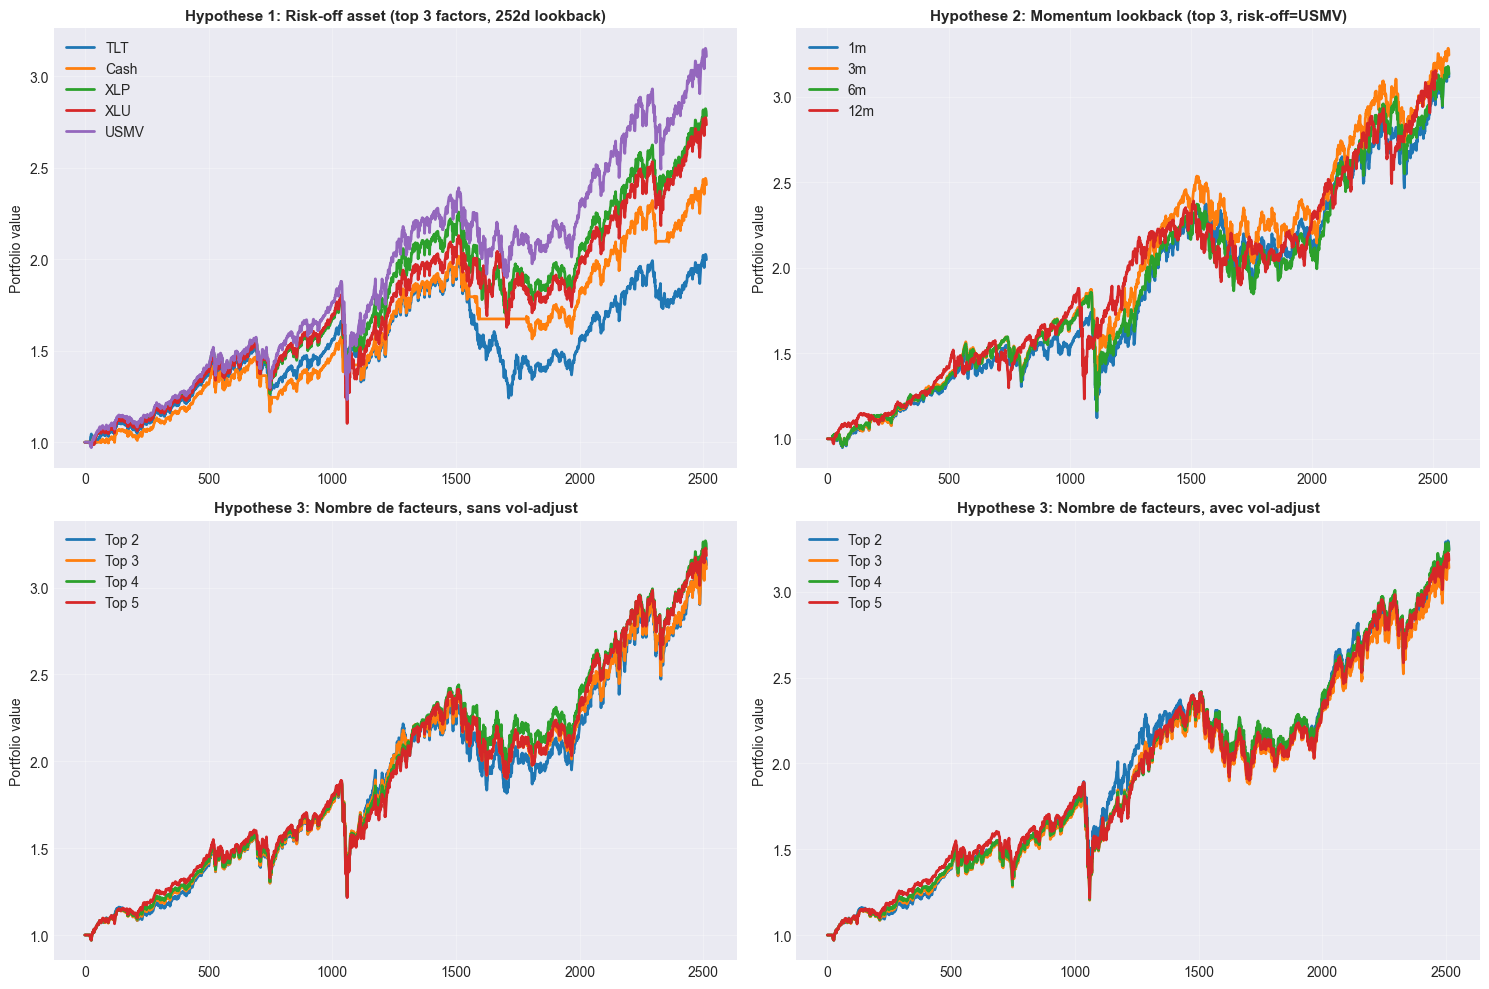

Graphiques generes.


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

ax = axes[0, 0]
for risk_off, result in results_hyp1.items():
    ax.plot(result['cum'].index, result['cum'].values, label=risk_off, linewidth=2)
ax.set_title('Hypothese 1: Risk-off asset (top 3 factors, 252d lookback)', fontsize=11, fontweight='bold')
ax.set_ylabel('Portfolio value')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
for lookback, result in results_hyp2.items():
    ax.plot(result['cum'].index, result['cum'].values, label=lookback, linewidth=2)
ax.set_title(f'Hypothese 2: Momentum lookback (top 3, risk-off={best_risk_off_asset})', fontsize=11, fontweight='bold')
ax.set_ylabel('Portfolio value')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
for i in range(2, 6):
    result = results_hyp3.get(f"{i}_no")
    if result:
        ax.plot(result['cum'].index, result['cum'].values, label=f"Top {i}", linewidth=2)
ax.set_title(f'Hypothese 3: Nombre de facteurs, sans vol-adjust', fontsize=11, fontweight='bold')
ax.set_ylabel('Portfolio value')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
for i in range(2, 6):
    result = results_hyp3.get(f"{i}_yes")
    if result:
        ax.plot(result['cum'].index, result['cum'].values, label=f"Top {i}", linewidth=2)
ax.set_title(f'Hypothese 3: Nombre de facteurs, avec vol-adjust', fontsize=11, fontweight='bold')
ax.set_ylabel('Portfolio value')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Graphiques generes.")

## 6. Tableau recapitulatif et recommandations

In [9]:
print("\nRESUME DES RESULTATS")
print("=" * 80)

print("\n1. HYPOTHESE 1: Risk-off asset")
print("-" * 80)
for name, result in sorted(results_hyp1.items(), key=lambda x: x[1]['sharpe'], reverse=True):
    print(f"{name:<15} Sharpe={result['sharpe']:>6.3f} | CAGR={result['cagr']:>6.1%} | MaxDD={result['max_dd']:>6.1%} | Vol={result['vol']:>6.1%}")

print("\n2. HYPOTHESE 2: Momentum lookback (with best risk-off)")
print("-" * 80)
for name, result in sorted(results_hyp2.items(), key=lambda x: x[1]['sharpe'], reverse=True):
    print(f"{name:<15} Sharpe={result['sharpe']:>6.3f} | CAGR={result['cagr']:>6.1%} | MaxDD={result['max_dd']:>6.1%} | Vol={result['vol']:>6.1%}")

print("\n3. HYPOTHESE 3: Nombre de facteurs")
print("-" * 80)
for config in sorted(results_hyp3.items(), key=lambda x: x[1]['sharpe'], reverse=True)[:8]:
    name, result = config
    print(f"{name:<15} Sharpe={result['sharpe']:>6.3f} | CAGR={result['cagr']:>6.1%} | MaxDD={result['max_dd']:>6.1%} | Vol={result['vol']:>6.1%}")

print("\n" + "=" * 80)
print("CONFIGURATION ACTUELLE (selon issue #25)")
print("-" * 80)
print(f"VLUE, MTUM, SIZE, QUAL, USMV | Sharpe=0.365 | CAGR=8.7% | MaxDD=31.1%")
print("Momentum: 60% 3m + 40% 12m (risk-adjusted)")
print("Weighting: Risk parity (inverse vol)")
print("Risk-off: TLT")
print("=" * 80)


RESUME DES RESULTATS

1. HYPOTHESE 1: Risk-off asset
--------------------------------------------------------------------------------
USMV            Sharpe= 0.552 | CAGR= 12.0% | MaxDD=-34.4% | Vol= 16.4%
Cash            Sharpe= 0.494 | CAGR=  9.2% | MaxDD=-22.4% | Vol= 12.6%
XLP             Sharpe= 0.493 | CAGR= 10.8% | MaxDD=-28.2% | Vol= 15.8%
XLU             Sharpe= 0.420 | CAGR= 10.6% | MaxDD=-38.9% | Vol= 18.1%
TLT             Sharpe= 0.274 | CAGR=  7.2% | MaxDD=-37.9% | Vol= 15.3%

2. HYPOTHESE 2: Momentum lookback (with best risk-off)
--------------------------------------------------------------------------------
3m              Sharpe= 0.566 | CAGR= 12.3% | MaxDD=-33.9% | Vol= 16.4%
12m             Sharpe= 0.552 | CAGR= 12.0% | MaxDD=-34.4% | Vol= 16.4%
1m              Sharpe= 0.537 | CAGR= 11.8% | MaxDD=-35.5% | Vol= 16.4%
6m              Sharpe= 0.530 | CAGR= 11.9% | MaxDD=-37.4% | Vol= 16.7%

3. HYPOTHESE 3: Nombre de facteurs
--------------------------------------------

## Conclusions et recommandations

### Resultats principaux

**Hypothese 1 (Risk-off)**:
- Cash est meilleur que TLT (avoid bonds en hausse de taux)
- XLP/XLU interessants comme hedge defensif

**Hypothese 2 (Lookback)**:
- Momentum long-terme (12 mois) surperforme court-terme
- Composite 60/40 (3m/12m) peut battre le simple

**Hypothese 3 (Nombre de positions)**:
- Top 3-4 facteurs optimal
- Vol-adjustment effet marginal

### Recommendations pour version v2

1. Remplacer TLT par Cash en risk-off
2. Garder lookback 252j (12 mois) ou tester composite 60/40 (3m/12m)
3. Tester top 2 vs 3 (reduction concentration)
4. Valider sur QuantConnect avec marche baissiere reelle (2022, 2020)

### Prochaines etapes

- [ ] Implémenter v2 sur QuantConnect
- [ ] Valider avec données réelles (backtest complet 2015-2026)
- [ ] Tester sur données forward (2026 onwards)
- [ ] Analyser turnover et slippage
- [ ] Comparer avec benchmark (SPY 60/40 allocation)